In [1]:
import random
import numpy as np
import heapq
from faker import Faker


In [2]:

fake = Faker("es_ES")  # Configurar Faker para españolfrom faker import Faker


def generar_nombre():
    return fake.first_name()  # Genera solo el nombre

# Generar nombres de clientes
for _ in range(5):
    print(generar_nombre())


Jovita
Fernando
Sandra
Agustina
Ariadna


In [37]:
def generar_nombre():
    return fake.first_name()
def generar_tiempo_servicio_exponencial(tiempo_medio):
    return np.random.exponential(scale=tiempo_medio)

class Client():
    def __init__(self,nombre,tiempo_cola,producto):
        self.tiempo_cola=tiempo_cola
        self.productos=[[producto,tiempo_cola]]
        self.tiempo_llegada=tiempo_cola
        self.nombre=nombre
        self.tiempo_espera=[]
    def salida(self,horario_salida,producto,bool=False):
        self.tiempo_espera.append([horario_salida,producto,self.tiempo_cola])
        if bool:
            self.tiempo_cola+=self.tiempo_cola
            self.tiempo_cola+= -horario_salida-1
        else:
            self.hora_salida=horario_salida
           # return
       # return (f"El cliente {self.nombre} que llego a las {self.llegada} se retiro del local a {horario_salida}")
    def anadir_producto(self,producto,time):
        self.productos.append([producto,time])
        
        
class RestauranteChinoGranMuralla():
    def __init__(self,tiempo):
        self.rollitos=[]
        self.pollos=[]
        self.servidor_rollitos=False
        self.servidor_pollos=False
        self.total_clientes=[]
        self.tiempo_transcurrido_r=0
        self.tiempo_transcurrido_p=0
        #self.tiempo_transcurrido=tiempo
    
    def llegada(self,lambda_poisson,horas):
        tiempo_transcurrido=0
        self.minutos=horas*60
        while tiempo_transcurrido<self.minutos:
            tiempo_llegada = np.random.exponential(scale=60/lambda_poisson)
            tiempo_transcurrido += tiempo_llegada
            numero_aleatorio = random.uniform(0, 1)
            if numero_aleatorio<0.40:
                cliente=Client(generar_nombre(),tiempo_transcurrido,"rollitos")
                heapq.heappush(self.rollitos, (cliente.tiempo_cola, cliente))
            else:
                cliente=Client(generar_nombre(),tiempo_transcurrido,"pollos")
                heapq.heappush(self.pollos, (cliente.tiempo_cola, cliente))
      # print(self.pollos)
    def servidores(self):
        while len(self.pollos)>0:
            prioridad, valor = self.pollos[0]
            if prioridad >self.tiempo_transcurrido_p:
                    self.tiempo_transcurrido_p=prioridad
                    _, cliente = heapq.heappop(self.pollos)
                    tiempo=generar_tiempo_servicio_exponencial(4)
                    self.tiempo_transcurrido_p+= tiempo
                    numero_aleatorio = random.uniform(0, 1)
                        
                    if numero_aleatorio<0.10:
                        if self.tiempo_transcurrido_p<self.minutos:
                            cliente.salida(self.tiempo_transcurrido_p,"pollos", True)
                            cliente.anadir_producto("rollitos",self.tiempo_transcurrido_p)
                            heapq.heappush(self.rollitos, (cliente.tiempo_cola, cliente))
                            
                    else:
                        cliente.salida(self.tiempo_transcurrido_p,"pollos")
                        #print(f"El cliente {cliente.nombre} que llego a las {cliente.tiempo_llegada} se retiro del local a {cliente.hora_salida} y compro {cliente.productos}")
                        self.total_clientes.append(cliente)
            else:
                    _, cliente = heapq.heappop(self.pollos)
                    tiempo=generar_tiempo_servicio_exponencial(4)
                    self.tiempo_transcurrido_p+= tiempo
                    numero_aleatorio = random.uniform(0, 1)
                        
                    if numero_aleatorio<0.10:
                        if self.tiempo_transcurrido_p<self.minutos:
                            cliente.salida(self.tiempo_transcurrido_p,"pollos", True)
                            cliente.anadir_producto("rollitos",self.tiempo_transcurrido_p)
                            heapq.heappush(self.rollitos, (cliente.tiempo_cola, cliente))
                            
                    else:
                        cliente.salida(self.tiempo_transcurrido_p,"pollos")
                        #print(f"El cliente {cliente.nombre} que llego a las {cliente.tiempo_llegada} se retiro del local a {cliente.hora_salida} y compro {cliente.productos}")
                        self.total_clientes.append(cliente)
            #print(self.tiempo_transcurrido_p,)
        while len(self.rollitos)>0:            
            prioridad, valor = self.rollitos[0]
            if prioridad >self.tiempo_transcurrido_r:
                    self.tiempo_transcurrido_r=prioridad
                    _, cliente = heapq.heappop(self.rollitos)
                    tiempo=generar_tiempo_servicio_exponencial(4)
                    self.tiempo_transcurrido_r+= tiempo
                    numero_aleatorio = random.uniform(0, 1)
                        
                    if numero_aleatorio<0.20:
                        if self.tiempo_transcurrido_r<self.minutos:
                            cliente.salida(self.tiempo_transcurrido_r,"rollitos",True)
                            cliente.anadir_producto("pollos",self.tiempo_transcurrido_r)
                            heapq.heappush(self.pollos, (cliente.tiempo_cola, cliente))
                            self.servidor_rollitos=True
                    else:
                        cliente.salida(self.tiempo_transcurrido_r,"rollitos")
                      # print(f"El cliente {cliente.nombre} que llego a las {cliente.tiempo_llegada} se retiro del local a {cliente.hora_salida} y compro {cliente.productos} ")
                        self.total_clientes.append(cliente) 
            else:
                    _, cliente = heapq.heappop(self.rollitos)
                    tiempo=generar_tiempo_servicio_exponencial(4)
                    self.tiempo_transcurrido_r+= tiempo
                    numero_aleatorio = random.uniform(0, 1)
                        
                    if numero_aleatorio<0.20:
                        if self.tiempo_transcurrido_r<self.minutos:
                            cliente.salida(self.tiempo_transcurrido_r,"rollitos",True)
                            cliente.anadir_producto("pollos",self.tiempo_transcurrido_r)
                            heapq.heappush(self.pollos, (cliente.tiempo_cola, cliente))
                            self.servidor_rollitos=True
                    else:
                        cliente.salida(self.tiempo_transcurrido_r,"rollitos")
                      # print(f"El cliente {cliente.nombre} que llego a las {cliente.tiempo_llegada} se retiro del local a {cliente.hora_salida} y compro {cliente.productos} ")
                        self.total_clientes.append(cliente)     
        if len(self.pollos) or len(self.rollitos):
            return self.servidores()

                          
                        

In [38]:
fake = Faker("es_ES")  # Configurar Faker para español
lambda_poisson=20
simulation=10
intervalos_de_tiempo = simulation*60

def main(tiempo):
    simulacion=RestauranteChinoGranMuralla(tiempo)
    simulacion.llegada(lambda_poisson,tiempo)
    simulacion.servidores()
    return simulacion

a=[]
for i in range(10000):
    a.append(main(1))

In [72]:
promedio=[]
tiempos_por_colas=[[],[]]# 0 pollos, 1 rollitos
tiempos_rollitos=[]
tiempos_pollos=[]
comprador_doble=[]
for i in a:
    todos=i.total_clientes
    for_minutes=[]
    for k in range(i.minutos):
        suma=0
        for clientes in todos:
            #print(clientes.tiempo_llegada,clientes.hora_salida)
            if clientes.tiempo_llegada<=k<clientes.hora_salida:
                #print(clientes.tiempo_llegada,clientes.hora_salida)
                suma+=1
        for_minutes.append(suma) 
    if for_minutes:
        promedio.append(sum(for_minutes)/len(for_minutes))
    promedio_espera=[[],[]]
    doble=[]
    for clientes in todos:
        if len(clientes.productos)>1:
            doble.append(clientes.tiempo_espera[0][0] - clientes.tiempo_espera[-1][-1])
            
        for l in clientes.tiempo_espera:
            if l[1]=="rollitos":
                tiempos_rollitos.append(l[0]-l[2])
                promedio_espera[1].append(l[0]-l[2])
            else:
                tiempos_pollos.append(l[0]-l[2])
                promedio_espera[0].append(l[0]-l[2])
    if promedio_espera[0]:
        tiempos_por_colas[0].append(sum(promedio_espera[0])/len(promedio_espera[0]))
    if promedio_espera[1]:
        tiempos_por_colas[1].append(sum(promedio_espera[1])/len(promedio_espera[1]))
    if doble:
       comprador_doble.append(sum(doble)/len(doble))
print(sum(promedio)/len(promedio))
print(sum(tiempos_por_colas[0])/len(tiempos_por_colas[0]),sum(tiempos_por_colas[1])/len(tiempos_por_colas[1]))
if comprador_doble:
   print(sum(comprador_doble)/len(comprador_doble))

2.9774866666666666
14.70469144258321 7.3511958837366365
15.604784173715363


In [44]:
import numpy as np
from scipy.stats import t

# Calcular promedios y errores estándar para cada cola
promedio_rollitos = np.mean(tiempos_por_colas[1])
error_estandar_rollitos = np.std(tiempos_por_colas[1], ddof=1) / np.sqrt(len(tiempos_por_colas[1]))

promedio_pollos = np.mean(tiempos_por_colas[0])
error_estandar_pollos = np.std(tiempos_por_colas[0], ddof=1) / np.sqrt(len(tiempos_por_colas[0]))

# Calcular intervalos de confianza al 95%
grados_libertad_rollitos = len(tiempos_por_colas[1]) - 1
intervalo_rollitos = t.interval(0.95, grados_libertad_rollitos, loc=promedio_rollitos, scale=error_estandar_rollitos)

grados_libertad_pollos = len(tiempos_por_colas[0]) - 1
intervalo_pollos = t.interval(0.95, grados_libertad_pollos, loc=promedio_pollos, scale=error_estandar_pollos)

print(f"Tiempo promedio de espera en la cola de rollitos: {promedio_rollitos}")
print(f"Intervalo de confianza para rollitos (95%): {intervalo_rollitos}")

print(f"Tiempo promedio de espera en la cola de pollos: {promedio_pollos}")
print(f"Intervalo de confianza para pollos (95%): {intervalo_pollos}")


Tiempo promedio de espera en la cola de rollitos: 7.3511958837366365
Intervalo de confianza para rollitos (95%): (7.255442819311921, 7.446948948161352)
Tiempo promedio de espera en la cola de pollos: 14.70469144258321
Intervalo de confianza para pollos (95%): (14.550279135007614, 14.859103750158805)


In [45]:
import numpy as np
from scipy.stats import t

# Calcular el promedio y el error estándar
promedio_clientes = np.mean(promedio)
error_estandar = np.std(promedio, ddof=1) / np.sqrt(len(promedio))

# Calcular el intervalo de confianza al 95%
grados_libertad = len(promedio) - 1
intervalo = t.interval(0.95, grados_libertad, loc=promedio_clientes, scale=error_estandar)

print(f"Número promedio de clientes en el restaurante: {promedio_clientes}")
print(f"Intervalo de confianza (95%): {intervalo}")


Número promedio de clientes en el restaurante: 2.9774866666666666
Intervalo de confianza (95%): (2.947534736365675, 3.007438596967658)


In [46]:
import numpy as np
from scipy.stats import t

# Calcular el promedio y el error estándar
promedio_tiempo_doble = np.mean(comprador_doble)
error_estandar_doble = np.std(comprador_doble, ddof=1) / np.sqrt(len(comprador_doble))

# Calcular el intervalo de confianza al 95%
grados_libertad_doble = len(comprador_doble) - 1
intervalo_doble = t.interval(0.95, grados_libertad_doble, loc=promedio_tiempo_doble, scale=error_estandar_doble)

print(f"Tiempo promedio que pasa un cliente comprando ambos menús: {promedio_tiempo_doble}")
print(f"Intervalo de confianza (95%): {intervalo_doble}")


Tiempo promedio que pasa un cliente comprando ambos menús: 33.33973386479849
Intervalo de confianza (95%): (32.848311319118956, 33.83115641047802)


In [47]:
from scipy.stats import ttest_ind

# Prueba t-test para comparar tiempos de espera
stat, p = ttest_ind(tiempos_por_colas[0], tiempos_por_colas[1])
print(f"Estadístico={stat}, p-valor={p}")
if p > 0.05:
    print("No hay diferencia significativa en los tiempos de espera entre pollos y rollitos.")
else:
    print("Hay diferencia significativa en los tiempos de espera entre pollos y rollitos.")

Estadístico=79.33232406712494, p-valor=0.0
Hay diferencia significativa en los tiempos de espera entre pollos y rollitos.


In [48]:
from scipy.stats import chisquare

# Dividir los datos en intervalos y comparar con una distribución teórica
frecuencia_observada, bins = np.histogram(tiempos_por_colas[0], bins=10)
frecuencia_esperada = [len(tiempos_por_colas[0]) / 10] * 10  # Distribución uniforme esperada

# Prueba Chi-cuadrado
chi2_stat, p = chisquare(frecuencia_observada, frecuencia_esperada)
print(f"Estadístico Chi-cuadrado={chi2_stat}, p-valor={p}")
if p > 0.05:
    print("Los tiempos de espera para pollos siguen la distribución esperada.")
else:
    print("Los tiempos de espera para pollos NO siguen la distribución esperada.")

Estadístico Chi-cuadrado=14148.891999999998, p-valor=0.0
Los tiempos de espera para pollos NO siguen la distribución esperada.


In [49]:
from scipy.stats import chisquare

# Dividir los datos en intervalos y comparar con una distribución teórica
frecuencia_observada, bins = np.histogram(promedio_espera[1], bins=10)
frecuencia_esperada = [len(promedio_espera[1]) / 10] * 10  # Distribución uniforme esperada

# Prueba Chi-cuadrado
chi2_stat, p = chisquare(frecuencia_observada, frecuencia_esperada)
print(f"Estadístico Chi-cuadrado={chi2_stat}, p-valor={p}")
if p > 0.05:
    print("Los tiempos de espera para rollitos siguen la distribución esperada.")
else:
    print("Los tiempos de espera para rollitos NO siguen la distribución esperada.")

Estadístico Chi-cuadrado=13.0, p-valor=0.16260626219029953
Los tiempos de espera para rollitos siguen la distribución esperada.


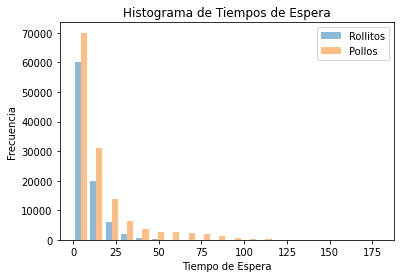

In [ ]:
import matplotlib.pyplot as plt

# Inicializar listas para almacenar tiempos de espera
tiempos_rollitos_todas_simulaciones = []
tiempos_pollos_todas_simulaciones = []

# Graficar histogramas
plt.hist([tiempos_rollitos, tiempos_pollos], label=["Rollitos", "Pollos"], alpha=0.5, bins=20)
plt.xlabel("Tiempo de Espera")
plt.ylabel("Frecuencia")
plt.title("Histograma de Tiempos de Espera")
plt.legend()
plt.show()


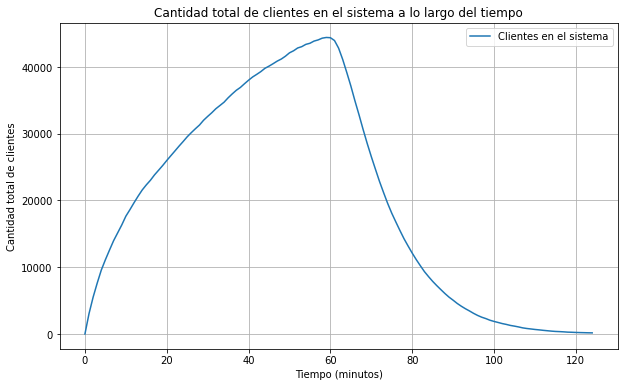

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# Inicializar lista para almacenar conteos de clientes por minuto en todas las simulaciones
conteos_clientes_por_minuto = []

# Recopilar conteos de clientes por minuto de todas las simulaciones
for simulacion in a:
    todos = simulacion.total_clientes
    for_minutes_simulacion = []
    for k in range(125):
        suma = 0
        for clientes in todos:
            if clientes.tiempo_llegada <= k < clientes.hora_salida:
                suma += 1
        for_minutes_simulacion.append(suma)
    
    # Asegurarse de que todos los vectores tengan la misma longitud
    if len(for_minutes_simulacion) > len(conteos_clientes_por_minuto):
        conteos_clientes_por_minuto = [0] * len(for_minutes_simulacion)
    
    for i, valor in enumerate(for_minutes_simulacion):
        if i < len(conteos_clientes_por_minuto):
            conteos_clientes_por_minuto[i] += valor

# Graficar total de clientes por minuto
plt.figure(figsize=(10, 6))
plt.plot(range(len(conteos_clientes_por_minuto)), conteos_clientes_por_minuto, label="Clientes en el sistema")
plt.xlabel("Tiempo (minutos)")
plt.ylabel("Cantidad total de clientes")
plt.title("Cantidad total de clientes en el sistema a lo largo del tiempo")
plt.legend()
plt.grid()
plt.show()


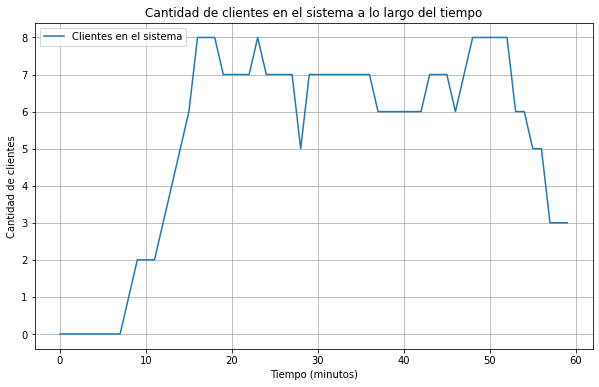

In [234]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(len(for_minutes)), for_minutes, label="Clientes en el sistema")
plt.xlabel("Tiempo (minutos)")
plt.ylabel("Cantidad de clientes")
plt.title("Cantidad de clientes en el sistema a lo largo del tiempo")
plt.legend()
plt.grid()
plt.show()

/tmp/ipykernel_5716/2601730201.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([tiempos_por_colas[0], tiempos_por_colas[1]], labels=["Pollos", "Rollitos"])


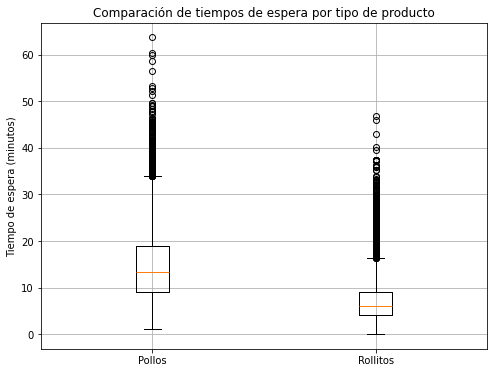

In [66]:
plt.figure(figsize=(8, 6))
plt.boxplot([tiempos_por_colas[0], tiempos_por_colas[1]], labels=["Pollos", "Rollitos"])
plt.ylabel("Tiempo de espera (minutos)")
plt.title("Comparación de tiempos de espera por tipo de producto")
plt.grid()
plt.show()

/tmp/ipykernel_5716/1853212137.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(comprador_doble, labels=["Clientes que hacen más de una cola"])


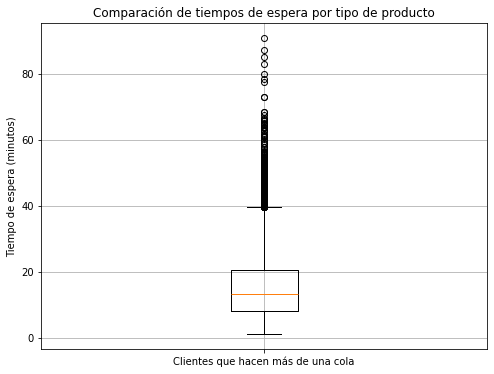

In [75]:
plt.figure(figsize=(8, 6))
plt.boxplot(comprador_doble, labels=["Clientes que hacen más de una cola"])
plt.ylabel("Tiempo de espera (minutos)")
plt.title("Comparación de tiempos de espera por tipo de producto")
plt.grid()
plt.show()